In [ ]:
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

enc = tiktoken.get_encoding("cl100k_base")


books = {
    "Moby Dick":  "https://www.gutenberg.org/files/2701/2701-0.txt",
    "Frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
    "Alice in Wonderland": "https://www.gutenberg.org/files/11/11-0.txt"
}

book_texts = {}
for name, url in books.items():
    with urllib.request.urlopen(url) as f:
        book_texts[name] = f.read().decode("utf-8")
    print(f"Downloaded: {name}")

Downloaded: Moby Dick
Downloaded: Frankenstein
Downloaded: Alice in Wonderland


In [ ]:
moby_tokens = enc.encode(book_texts["Moby Dick"])

token_lengths = [len(enc.decode([t])) for t in moby_tokens]

print(f"Total tokens: {len(token_lengths)}")
print(f"Shortest token: {min(token_lengths)} characters")
print(f"Longest token:  {max(token_lengths)} characters")
print(f"Average length: {sum(token_lengths)/len(token_lengths):.2f} characters")

Total tokens: 307614
Shortest token: 1 characters
Longest token:  17 characters
Average length: 3.96 characters


In [3]:
longest_token_id = max(moby_tokens, key=lambda t: len(enc.decode([t])))
longest_token_str = enc.decode([longest_token_id])

print(f"Sabse lamba token: '{longest_token_str}'")
print(f"Length: {len(longest_token_str)} characters")

Sabse lamba token: ' responsibilities'
Length: 17 characters


In [4]:
import pandas as pd

lengths_series = pd.Series(token_lengths)

freq_table = lengths_series.value_counts().sort_index()
freq_table.name = "Count"
freq_table.index.name = "Token Length"


freq_df = pd.DataFrame(freq_table)
freq_df["Percentage"] = (freq_df["Count"] / len(token_lengths) * 100).round(2)

print(freq_df.to_string())

              Count  Percentage
Token Length                   
1             50449       16.40
2             28360        9.22
3             56924       18.51
4             62496       20.32
5             46750       15.20
6             26018        8.46
7             14544        4.73
8             10300        3.35
9              5659        1.84
10             3264        1.06
11             1552        0.50
12              720        0.23
13              377        0.12
14              154        0.05
15               38        0.01
16                8        0.00
17                1        0.00


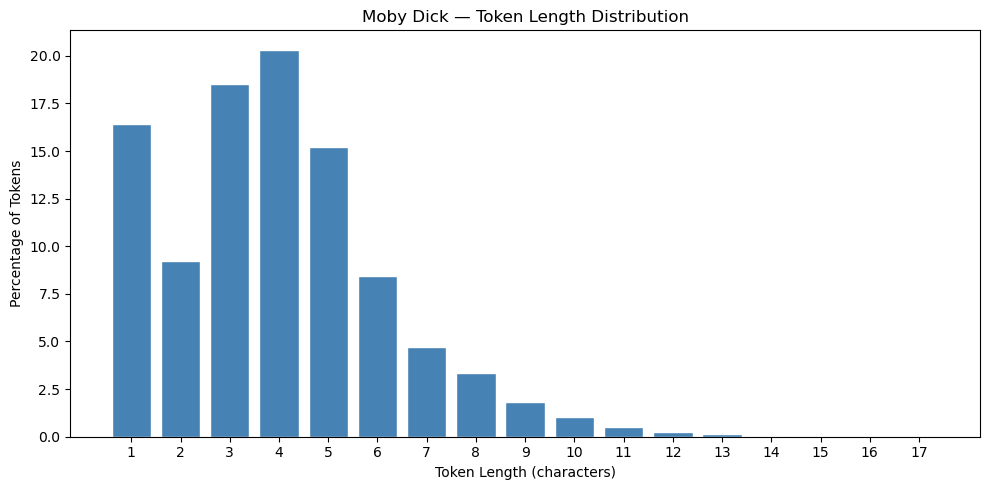

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(freq_df.index, freq_df["Percentage"], color="steelblue", edgecolor="white")

plt.xlabel("Token Length (characters)")
plt.ylabel("Percentage of Tokens")
plt.title("Moby Dick — Token Length Distribution")
plt.xticks(range(1, 18))

plt.tight_layout()
plt.show()

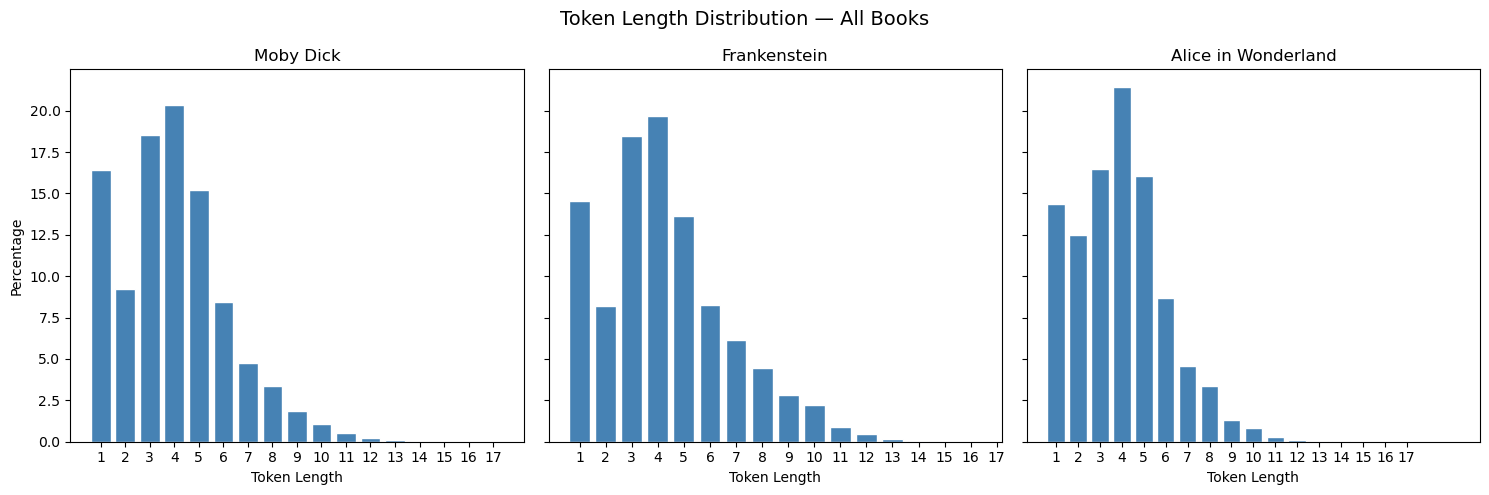

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (name, text) in zip(axes, book_texts.items()):
    
    tokens = enc.encode(text)
    lengths = [len(enc.decode([t])) for t in tokens]
    
    
    s = pd.Series(lengths)
    freq = s.value_counts(normalize=True).sort_index() * 100
    
    ax.bar(freq.index, freq.values, color="steelblue", edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("Token Length")
    ax.set_xticks(range(1, 18))

axes[0].set_ylabel("Percentage")
fig.suptitle("Token Length Distribution — All Books", fontsize=14)

plt.tight_layout()
plt.show()



* Most English tokens are typically **3–5 characters long**.

* The distribution of token lengths usually follows a **bell-shaped curve** (normal-like distribution).

* This pattern remains **consistent across different books**, showing stability in how language is tokenized.

* Tokens can be as long as **17 characters**, but such cases are **very rare**.
